# Sailing Route Optimization with Q-Learning

## Introduction

Sailing can be hard and not always intuitive, especially when racing. Typically a sailboat race has a starting line/finishing line and two marks (waypoints). A windward mark, and a leeward mark. Before we move on, let's go over some terminology.

- **Windward-Leeward Course**:
    - A typical sailboat race course configuration.
    - You have a start-finish line in the center of the course, that is perpendicular to the direction of the wind.
    - A windward mark and leeward mark you have to sail around.
- **Windward Mark**: The mark that is upwind of the start-finish line.
- **Leeward Mark**: The mark that is downwind of the start-finish line.
- **Point of Sail**: The angle off the wind you are sailing. The diagram below illustrates the different points of sail.
- **Tack Maneuver**: A sailing maneuver where you swing your bow across wind to change direction (*tack*). 
- **Velocity Made Good (VMG)**: The component of your velocity headed towards the mark.
    - Example: The mark is due North of your current location, but you are travelling North-Northeast at 5 knots. Your VMG will be less than 5 knots, since you are moving *away* from the mark along the x-axis, but it will be greater than 0 since you are moving *towards* the mark along the y-axis.

Usually, the race starts going to the upwind mark. This is tricky, because a sailboat cannot travel directly into the wind. At best, a boat can usually sail 30 degrees off of the wind. This point of sail is called close-hauled. This has several effects:
1. Since you can't sail directly to the mark, you typically take a zig-zag type route upwind to it.
2. Since you are close-hauled, any subtle (or major) shift in the wind will have an impact on your velocity made good.
3. When you tack, you temporarily lose velocity, since as you swing your bow across the wind, your sails will not be powered.

<img src="points_of_sail.jpg" width=1024 height=1024/>

## Purpose

The purpose of this project is to see if an agent can learn to sail a boat the optimal path to a given waypoint, with the following information provided to the agent:

- **relative_wind_direction**: The direction (angle) of the wind relative to the agent's current velocity vector.
- **relative_bearing_wp**: The direction (angle) of the waypoint relative to the agent's current velocity vector.

The goal is for the agent to be able to sail efficiently to any waypoint, regardless of bearing and wind direction.

<img src="relative_bearing.jpg" width=1024 height=1024/>

## Code
As with any project, the first step is to import the required libraries.

In [1]:
import numpy as np
from tqdm import tqdm
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import math
import pickle
from collections import defaultdict
from skspatial.objects import Line, Point

### Boat Object

The boat object will have 6 attributes and 4 methods.

Three of the attributes save the boat's initial state:
- init_direction
- init_velocity
- init_position

The other three maintain the current state of the boat:

- direction
- position
- velocity

The functions are:

- reset(): Resets the state of the boat to its initial state.
- update_position(): updates the position of the boat, based on its velocity and direction
- update_direction(action): Updates the direction of the boat, based on an inputted action. Actions include:
    - No change in direction
    - Slight change to the port (left)
    - Slight change in direction to the starboard (right)
    - Large change in direction to port
    - Large change in direction to starboard
- update_velocity(wind_direction, wind_velocity): Updates velocity of the boat based on the wind direction and wind velocity, relative to the direction and velocity of the boat. The function used to determine boat velocity simulates a sailboat's polar diagram, and was borrowed from [Paweł A. Pierzchlewicz](https://perceptron.blog/about) blog post [ai-learns-to-sail-upwind](https://perceptron.blog/ai-learns-to-sail-upwind/)

In [2]:
class Boat:
    def __init__(self, direction=90, position=np.array([0.0,0.0]), velocity=0.0):

        self.direction = direction
        self.position = position.copy()
        self.velocity = velocity

        self.init_direction = direction
        self.init_velocity = velocity
        self.init_position = position.copy()

    def reset(self):
        self.direction = self.init_direction
        self.position = self.init_position.copy()
        self.velocity = self.init_velocity
        return

    def update_position(self):
        radians = math.radians(self.direction)
        # update x
        self.position[0] += np.cos(radians) * self.velocity
        # update y
        self.position[1] += np.sin(radians) * self.velocity
        return

    def update_direction(self, action):
        if action == 0:  # straight
            self.direction = self.direction
        elif action == 1:  # port turn
            self.direction -= 4
            self.direction = int(self.direction % 360)
        elif action == 2:  # starboard turn
            self.direction += 4
            self.direction = int(self.direction % 360)
        elif action == 3:  # starboard tack
            self.direction += 30
            self.direction = int(self.direction % 360)
        elif action == 4:  # port turn
            self.direction -= 30
            self.direction = int(self.direction % 360)
        return

    def update_velocity(self, wind_direction, wind_velocity):
        diff = np.abs(self.direction - wind_direction) % 360
        diff = min(diff, 360 - diff)
        diff_rads = math.radians(diff)
        self.velocity = wind_velocity * (1 - np.exp(-(diff_rads ** 2) / (np.pi / 12)))
        return

### Waypoint Object

The waypoint object will require 1 of its two potential attributes. The attributes will determine the position of the boat.

- position: If the user wishes to manually select the coordinates of the waypoint, they can do so by entering a NumPy array containing X and Y coordinates.
- radius: If the user wishes to have the waypoint randomly generated along a circle centered on X=0, Y=0, they can specify the radius of the circle with this attribute.

This object has two functions:

- reset(set_wp, position): If no inputs are provided, this function will randomly reset the waypoint along the defined circle.
- generate_random_wp_along_circumference(): Function used to generate random location of a waypoint along the defined circle.

In [3]:
class WayPoint:
    def __init__(self,position=None,radius=1_500.0):
        self.radius=radius
        if type(position) == np.ndarray:
            self.init_position = position.copy()
        else:
            self.init_position = None

        if position is None:
            self.generate_random_wp_along_circumference()
        else:
            self.position = position
        # do something
        return

    def reset(self,set_wp=False,position=None):
        if set_wp:
            self.position=position
            self.init_position=position
        elif self.init_position is None:
            self.generate_random_wp_along_circumference()
        else:
            self.position = self.init_position.copy()
        return

    def generate_random_wp_along_circumference(self):
        angle = np.random.uniform(0.0, 2.0 * np.pi)
        x = self.radius * np.cos(angle)
        y = self.radius * np.sin(angle)
        self.position = np.array([x, y])
        return

### Wind Object

The wind object has 4 attributes and 3 methods. The attributes are:

- direction: Direction of the wind
- velocity: Velocity of the wind
- init_direction: Initial direction of the wind
- init_velocity: Initial velocity of the wind

The methods are:

- update_velocity(): Velocity of wind is randomly updated based on a normal distribution. The velocity is capped between 1 and 10.
- update_direction(): Direction is randomly updated based on a normal distribution. The wind has a 20% chance of changing.

In [4]:
class Wind:
    def __init__(self, velocity=5, direction=90):
        self.direction = direction
        self.velocity = velocity

        self.init_direction = direction
        self.init_velocity = velocity

    def reset(self):
        self.direction = self.init_direction
        self.velocity = self.init_velocity
        return

    def update_velocity(self):
        self.velocity = int(np.round(np.random.normal(self.velocity, 1)))
        if self.velocity > 10:
            self.velocity = 10
        elif self.velocity < 1:
            self.velocity = 1
        return

    def update_direction(self):
        if np.random.randint(0, 5) == 4:  # 20% chance of wind shift
            new_wind_direction = int(np.round(np.random.normal(self.direction, 2)))
            self.direction = int(new_wind_direction % 360)
        return

### Sailing Environment Object
Our simulated sailing environment object is called SailingWorld and inherits from the gym.Env class. The environment has 3 primary attributes, as well as 5 attributes for tracking calculations. Then it has 6 methods.

The three primary attributes are:

- boat: An instance of the boat object
- wind: An instance of the wind object
- wp: An instance of the waypoint object

The other attributes are:

- dist_to_wp: The distance between the boat and waypoint
- true_bearing_wp: The true direction to the waypoint from position of the boat.
- relative_wind_direction: The direction of the wind relative to the direction of the boat.
- relative_bearing_wp: The relative direction of the waypoint from the position *and* direction of the boat.
- action_space: All possible actions the agent can take to affect the boat.

The primary methods for this class are the step() and reset() methods. The step method is how the agent will control the boat and interact with the environment. The reset() method is important for training, since we will have to iterate multiple times. This makes it to where we don't have to re instantiate everything every iteration.

- step(action): Given an inputted action, the state of the environment is then updated.
- reset(): Resets the entire environment.

The other methods are as follows:

- get_relative_direction(A,B): Gets the relative direction between two points, A and B.
- get_true_bearing_wp(): Gets the true bearing between boat and waypoint.
- _get_state(): Returns dictionary of data needed for agent to make a decision on next action.
    - relative_wind_direction
    - relative_bearing_wp
- _get_info(): Returns dictionary of data that can be used to evaluate and analyze agent performance.

In [5]:
class SailingWorld(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}
    def __init__(self, render_mode=None, size=5, boat=Boat(),wp=WayPoint(),wind=Wind()):
        self.boat = boat
        self.wind = wind
        self.wp = wp

        # ENHANCED FIELDS
        self.dist_to_wp = np.linalg.norm(self.boat.position - self.wp.position)
        self.get_true_bearing_wp()
        self.relative_wind_direction = self.get_relative_direction(self.wind.direction,self.boat.direction)
        self.relative_bearing_wp = self.get_relative_direction(self.true_bearing_wp,self.boat.direction)

        self.action_space = spaces.Discrete(5)
        return

    def get_relative_direction(self,A,B):
        relative_direction = int((A - B) % 360)
        return relative_direction


    def get_true_bearing_wp(self):
        A = self.boat.position
        B = self.wp.position
        Adj = B[0] - A[0]
        Opp = B[1] - A[1]
        self.true_bearing_wp = int(math.degrees(math.atan2(Opp, Adj)) % 360)
        return


    def _get_state(self):
        return {
            "relative_wind_direction": self.relative_wind_direction,
            "relative_bearing_wp": self.relative_bearing_wp,
        }

    def _get_info(self):
        return {
            "boat_position": self.boat.position,
            "boat_velocity":self.boat.velocity,
            "boat_direction":self.boat.direction,
            "wind_direction":self.wind.direction,
            "wind_velocity":self.wind.velocity,
            "wp_position": self.wp.position
        }

    def reset(self, seed=None, options=None, render_mode=None, size=5,set_wp=False,wp_position=None):

        # We need the following line to seed self.np_random
        #super().reset(seed=seed)
        self.boat.reset()

        self.wind.reset()
        self.wp.reset(set_wp,wp_position)

        # ENHANCED FIELDS
        self.dist_to_wp = np.linalg.norm(self.boat.position - self.wp.position)
        self.get_true_bearing_wp()
        self.relative_wind_direction = self.get_relative_direction(self.wind.direction,self.boat.direction)
        self.relative_bearing_wp = self.get_relative_direction(self.true_bearing_wp,self.boat.direction)

        # Data for Agent
        info = self._get_info()
        state = self._get_state()

        return state, info


    def step(self, action):

        # UPDATE BOAT DIRECTION
        self.boat.update_direction(action)

        # UPDATE BOAT VELOCITY
        self.boat.update_velocity(self.wind.direction,self.wind.velocity)

        # UPDATE BOAT POSITION
        old_dist_to_wp = self.dist_to_wp
        self.boat.update_position()
        self.dist_to_wp = np.linalg.norm(self.boat.position - self.wp.position)

        # UPDATE WIND DIRECTION
        self.wind.update_direction()

        # UPDATE WIND VELOCITY
        self.wind.update_velocity()

        # UPDATE WM TRUE BEARING
        self.get_true_bearing_wp()
        # ENHANCED FIELDS
        self.relative_wind_direction = self.get_relative_direction(self.wind.direction,self.boat.direction)
        self.relative_bearing_wp = self.get_relative_direction(self.true_bearing_wp,self.boat.direction)


        reward = old_dist_to_wp - self.dist_to_wp
        # GATHER DATA
        terminated = self.dist_to_wp < 10
        state = self._get_state()
        info = self._get_info()
        return state, reward, terminated, False, info

We are going to create an instance of the SailingWorld environment here, so we can utilize some of its attributes in the SailboatRacingAgent class.

In [6]:
env = SailingWorld()

### QLearning Agent Object
This is the object containing the agent data in Q-Learning. This data includes a variety of hyperparameters, stored as attributes, as well as attributes maintaining the Q-Table values, and action space. 

- q_values: A dictionary of states-action values initialized at zero. Filled out during training.
- action_space: All possible actions an agent can take.
- lr: Learning rate. Hyperparameter for how big of step taken when learning.
- discount_factor: Weights reward to prevent an infinite reward on infinite timestep problems.
- epsilon: Hyperparameter for determining probability that agent explores (ie. tries a random action), vs selects learned best action from experience.
- epsilon_decay: Typically, epsilon starts high (high rate of exploring), and decays over time, such that the agent begins relying more and more on what it has learned. This hyperparameter determines how quickly it moves to relying on what it has learned.
- final_epsilon: Hyperparameter that determines the lowest epsilon we will have.
- training_error: Keeps track of training error.

There are also 6 methods in this class.

- save_q_tables(filepath): Saves the q_table to the inputted filepath.
- load_q_tables(filepath): Loads the q_table from the inputted filepath.
- get_action(): Action selection based on state, q_table, and epsilon.
- update(): Updates q_table based on reward received after an action.
- decay_epsilon(): Function for decaying epsilon.
- run(env, training, n_episodes, n_steps, save_position): Loops through either an episode, or series of episodes. Will update q_table if training is set to True.

In [7]:
class QLearningAgent:
    def __init__(
            self,
            action_space: spaces.discrete.Discrete,
            learning_rate: float,
            initial_epsilon: float,
            epsilon_decay: float,
            final_epsilon: float,
            discount_factor: float = 0.95,
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.q_values = defaultdict(lambda: np.zeros(action_space.n))
        self.action_space = action_space
        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []
        return

    def save_q_tables(self, filepath):
        temp = self.q_values
        pickle.dump(dict(temp), open(filepath, 'wb'))
        return

    def load_q_tables(self, filepath):
        temp = pickle.load(open(filepath, 'rb'))
        self.q_values = defaultdict(lambda: np.zeros(self.action_space.n))
        for key in temp.keys():
            self.q_values[key] = temp[key]
        return

    def get_action(self, obs: tuple[int, int, int, int]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return self.action_space.sample()


        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
            self,
            obs: tuple[int, int],
            action: int,
            reward: float,
            terminated: bool,
            next_obs: tuple[int, int],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
                reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )
        self.q_values[obs][action] = (
                self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
        return

    def run(self,
               env,
               training=True,
               n_episodes=2_000,
               n_steps=400,
               save_position=False):
        REWARDS = []
        X = []
        Y = []
        WP_POS = []
        for _ in tqdm(range(n_episodes)):
            if save_position:
                x = []
                y = []
            rewards = 0
            obs, info = env.reset()
            obs_tup = tuple([v for v in obs.values()])

            for i in range(n_steps):
                action = self.get_action(obs_tup)
                next_obs, reward, terminated, truncated, info = env.step(action)
                next_obs_tup = tuple([v for v in next_obs.values()])

                # If training, then Update Agent
                if training:
                    self.update(obs_tup, action, reward, terminated, next_obs_tup)
                if save_position:
                    x.append(env.boat.position[0])
                    y.append(env.boat.position[1])
                rewards += reward
                # update if the environment is done and the current obs
                done = terminated or truncated
                if done:
                    break
                obs = next_obs
                obs_tup = tuple([v for v in obs.values()])

            if training:
                self.decay_epsilon()
            if save_position:
                X.append(x)
                Y.append(y)
            REWARDS.append(rewards)
            WP_POS.append(env.wp.position)
        return X, Y, WP_POS, REWARDS

## Q-Learning Algorithm
The function below defines the Q-Learning Algorithm.

1. Parameters are set.
2. For each episode:
    1. Reset environment.
    2. For each step in episode:
        1. Agent selects action.
        2. Environment is updated based on agent action.
        3. Q-table is updated based on action, environment state, and reward.

In [8]:
def Q_Learning(agent,
               env,
               training=True,
               n_episodes=2_000,
               n_steps=400,
               save_position=False):
    REWARDS = []
    X = []
    Y = []
    WP_POS = []
    random_wp = False

    for episode in tqdm(range(n_episodes)):
        if save_position:
            x = []
            y = []
        rewards = 0

        obs, info = env.reset()
        obs_tup = tuple([v for v in obs.values()])

        for i in range(n_steps):
            action = agent.get_action(obs_tup)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_obs_tup = tuple([v for v in next_obs.values()])

            # If training, then Update Agent
            if training:
                agent.update(obs_tup, action, reward, terminated, next_obs_tup)
            if save_position:
                x.append(env.boat.position[0])
                y.append(env.boat.position[1])
            rewards += reward
            # update if the environment is done and the current obs
            done = terminated or truncated
            if done:
                break
            obs = next_obs
            obs_tup = tuple([v for v in obs.values()])

        if training:
            agent.decay_epsilon()
        if save_position:
            X.append(x)
            Y.append(y)
        REWARDS.append(rewards)
        WP_POS.append(env.wp.position)
    return X, Y, WP_POS, REWARDS


## Training

Here we declare our hyperparameters, and instantiate our environment and agent.


In [9]:
# hyperparameters
learning_rate = 0.001
start_epsilon = 1.0
n_episodes=1_500
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.001
discount_factor = 0.95

env = SailingWorld(wp=WayPoint(radius=1_000))
env = gym.wrappers.RecordEpisodeStatistics(env, deque_size=n_episodes)


agent = QLearningAgent(
    action_space=env.action_space,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor,
)


Before we begin training, let's save how the agent behaves without any training. 

In [10]:
n=100
wp = np.array([0.0,1000.0])
env.env.reset(set_wp=True,wp_position=wp)
pX, pY, pWP_POS,_  = Q_Learning(agent,env,training=False,n_episodes=n,n_steps=400,
                                  save_position=True)


100%|██████████| 100/100 [00:02<00:00, 35.47it/s]


Now we are training the agent.

In [11]:
env.wp.init_position=None
env.env.reset(set_wp=False)

X, Y, WP_POS, REWARDS= agent.run(
    env=env,
   training=True,
   n_episodes=n_episodes,
   n_steps=400,
   save_position=True)

100%|██████████| 1500/1500 [00:45<00:00, 32.88it/s]



Below we set a static waypoint due North 1,000 units from the boat. The agent has 400 time steps to get the boat to the waypoint, and 100 chances to do so. 

You can see plots of how the agent does prior to training as well as how it does after. Prior to training, its movements are random. After training you can see much more of a pattern in behavior. Notice too, the zig-zag maneuvering going upwind!

In [12]:
n=100
wp = np.array([0.0,1000.0])
env.env.reset(set_wp=True,wp_position=wp)
aX, aY, aWP_POS,_  = Q_Learning(agent,env,training=False,n_episodes=n,n_steps=400,
                                  save_position=True)

100%|██████████| 100/100 [00:02<00:00, 38.33it/s]


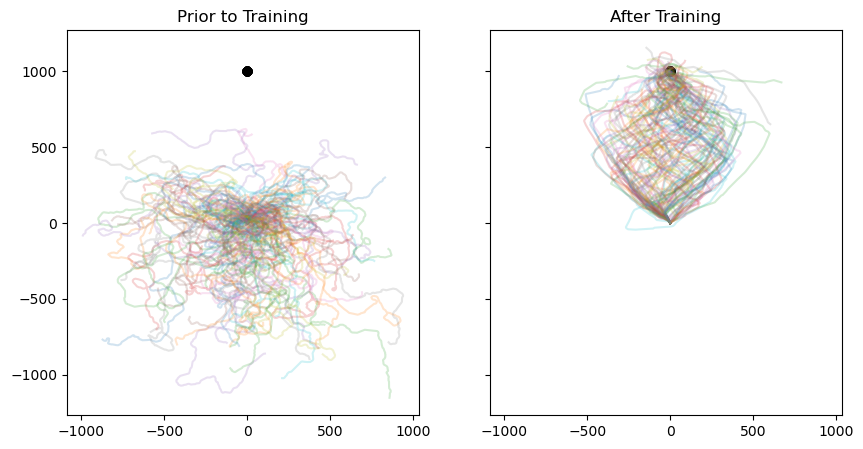

In [13]:
fig, axs = plt.subplots(1, 2,figsize=(10, 5),sharex=True, sharey=True)
def _plots(axis,x,y,wppos,title):
    n=100
    for i in range(0,n):
        axis.plot(x[i],y[i],alpha=0.2)
        axis.scatter(wppos[i][0],wppos[i][1],color="black")
    axis.set_title(title)
    #axis[0, 0].grid(True)

_plots(axs[0],pX, pY, pWP_POS, "Prior to Training")
_plots(axs[1],aX, aY, aWP_POS, "After Training")

Below you can see the agent's cumulative reward per episode increase over time.

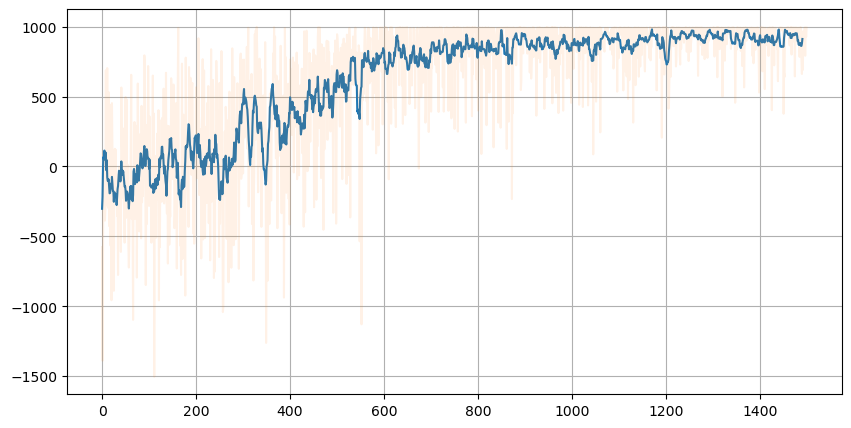

In [14]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n
ma_rewards = moving_average(REWARDS, n=10)
plt.figure(figsize=(10,5))
plt.plot(ma_rewards,alpha=1)
plt.plot(REWARDS,alpha=0.1)

plt.grid(True)
plt.show()

Below we can visualize the routes taken over the course of training. Again notice, as training progresses, movement gets significantly more deliberate and you can see logic and patterns in the routes being taken.

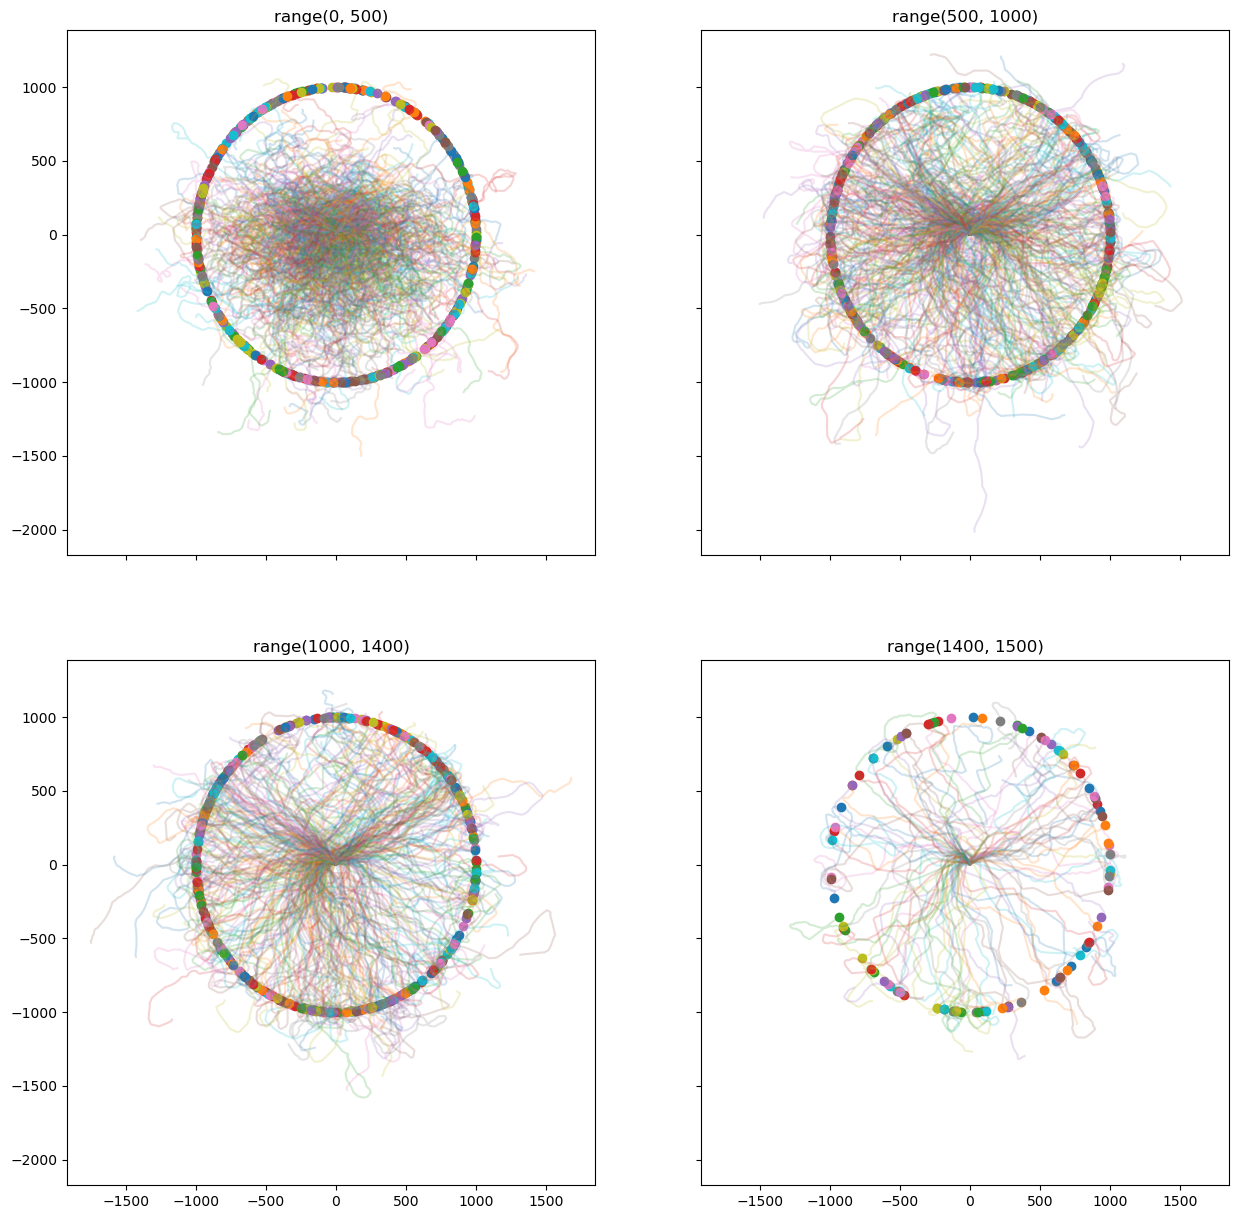

In [15]:
fig, axs = plt.subplots(2, 2,figsize=(15, 15),sharex=True, sharey=True)
def _plots(axis,r):
    for i in r:
        axis.scatter(WP_POS[i][0],WP_POS[i][1])
        axis.plot(X[i],Y[i],alpha=0.2)
    axis.set_title(str(r))
    #axis[0, 0].grid(True)

_plots(axs[0,0],range(0,500))
_plots(axs[0,1],range(500,1_000))
_plots(axs[1,0],range(1_000,1_400))
_plots(axs[1,1],range(1_400,1_500))
for ax in fig.get_axes():
    ax.label_outer()

Finally, we'll peek at how the trained agent performs at different points of sail.

100%|██████████| 3/3 [00:00<00:00, 51.06it/s]


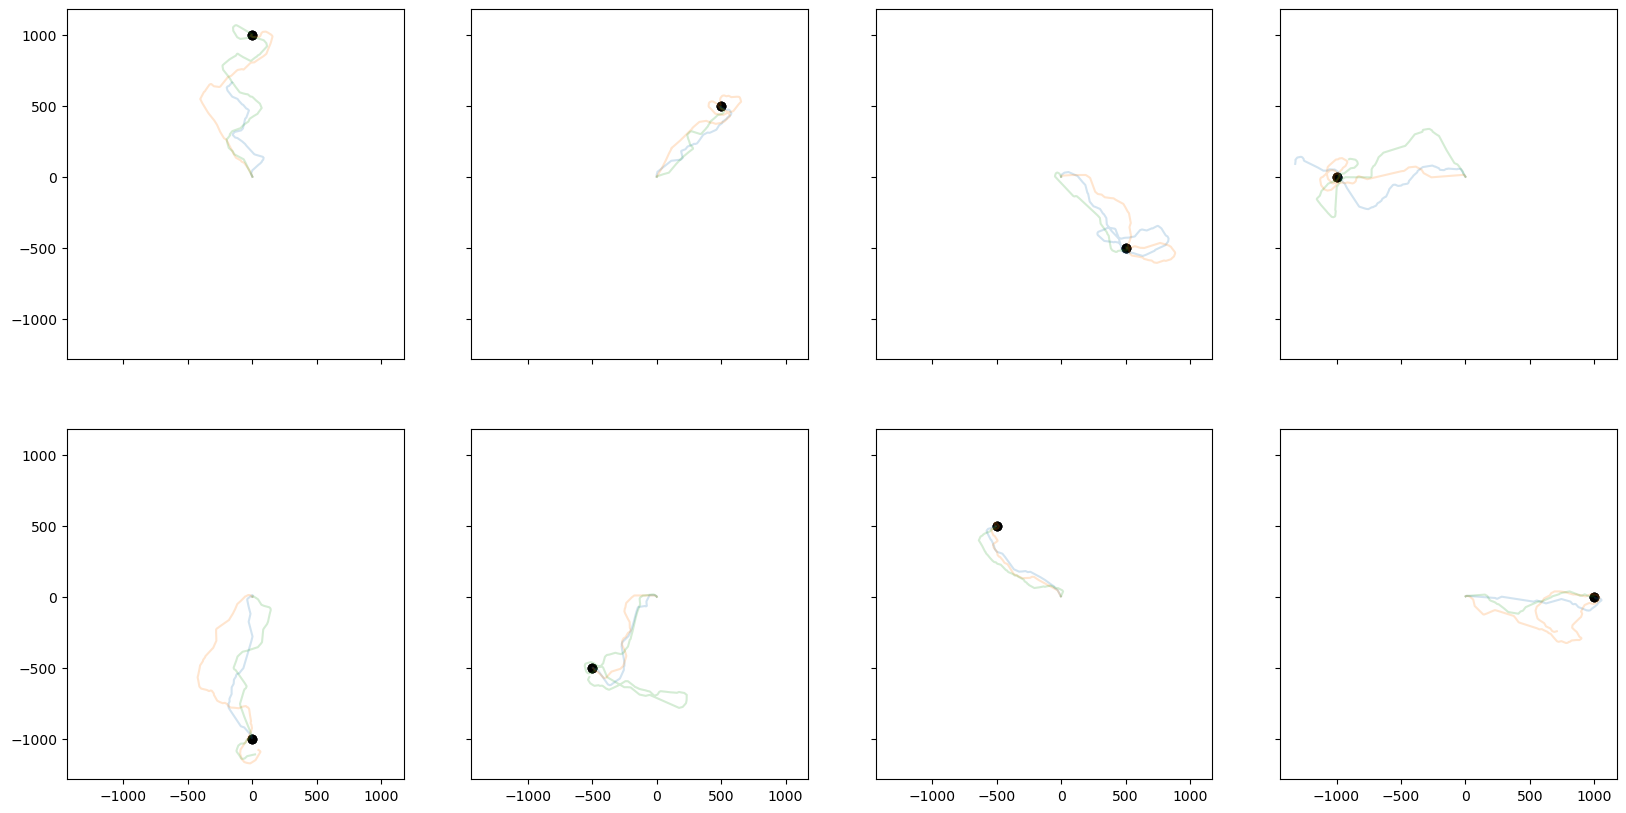

In [16]:
fig, axs = plt.subplots(2,4,figsize=(20, 10),sharex=True, sharey=True)
def _plots(axis,wp):
    n=3
    env.env.reset(set_wp=True,wp_position=wp)
    X, Y, WP_POS,_  = Q_Learning(agent,env,training=False,n_episodes=n,n_steps=400,
                                      save_position=True)
    for i in range(0,n):
        axis.plot(X[i],Y[i],alpha=0.2)
        axis.scatter(WP_POS[i][0],WP_POS[i][1],color="black")
    

_plots(axs[0,0],np.array([0.0,1_000.0]))
_plots(axs[0,1],np.array([500.0,500.0]))
_plots(axs[0,2],np.array([500.0,-500.0]))
_plots(axs[0,3],np.array([-1_000.0,0.0]))
_plots(axs[1,0],np.array([0.0,-1_000.0]))
_plots(axs[1,1],np.array([-500.0,-500.0]))
_plots(axs[1,2],np.array([-500.0,500.0]))
_plots(axs[1,3],np.array([1_000.0,0.0]))
for ax in fig.get_axes():
    ax.label_outer()

## Conclusion

Overall, the agent's performance increases significantly and measurably after training. This is illustrated in the many visualizations above.

I believe there are likely different approaches that could further enhance performance. Routes are not necessarily incorrect, but visually, they don't appear to be optimal.

Some things to try:

- Different reward functions. Currently we're maximizing each distance gained towards the waypoint each time step.
- Different action space. Currently there are 5 actions: no change in direction | small turn left | big turn left | small turn right | big turn right
- Different learning algorithm.
- Different state variables shared. Right now, the agent only has knowledge of the wind direction relative to the boat, and the direction of the WP relative to the boat.


This was a fun project, and I'll need to expand on it at some point!